In [1]:
print("Hello. This is a script that will plot roofline and where a kernel is on it.")

Hello. This is a script that will plot roofline and where a kernel is on it.


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION: Theoretical Peaks (SXM5 Variants) ---
# Values approximate for A100 (40GB) and H100 (80GB)
gpu_configs = {
    'A100_FP32': {'peak_flops': 19500, 'peak_bw': 1935},   # Standard CUDA Cores
    'A100_TF32': {'peak_flops': 156000, 'peak_bw': 1935},  # TF32 Tensor Cores
    'A100_FP16': {'peak_flops': 312000, 'peak_bw': 1935}   # FP16 Tensor Cores
}

def plot_roofline(gpu_name, kernel_flops, kernel_bytes, kernel_time_ns):
    config = gpu_configs[gpu_name]
    peak_flops = config['peak_flops']
    peak_bw = config['peak_bw']
    
    # 1. Calculate Kernel Stats
    # AI = Total Flops / Total Bytes
    ai = kernel_flops / kernel_bytes
    # GFLOPS = (Total Flops / 1e9) / (Time in seconds)
    achieved_gflops = (kernel_flops / 1e9) / (kernel_time_ns / 1e9)
    
    # 1. Expand the range to cover the kernel's AI
    ai_range = np.logspace(-2, 3, 500) # Go up to 1000 AI
    
    # 2. Ensure the roofline reflects the peak_flops ceiling
    roofline = np.minimum(peak_flops, peak_bw * ai_range)
    
    # 3. Force the Y-axis to show the peak
    plt.ylim(10, peak_flops * 1.5)
    
    # 3. Plotting
    plt.figure(figsize=(10, 6))
    plt.loglog(ai_range, roofline, label=f'{gpu_name} Roofline', color='black', lw=2)
    plt.scatter(ai, achieved_gflops, color='red', marker='x', s=100, label='Your Kernel')
    
    # Efficiency calculation
    theoretical_max = min(peak_flops, peak_bw * ai)
    efficiency = (achieved_gflops / theoretical_max) * 100
    
    plt.title(f'Roofline Analysis: {gpu_name}\nEfficiency: {efficiency:.2f}% of Theoretical Max')
    plt.xlabel('Arithmetic Intensity (FLOP/Byte)')
    plt.ylabel('Performance (GFLOP/s)')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()

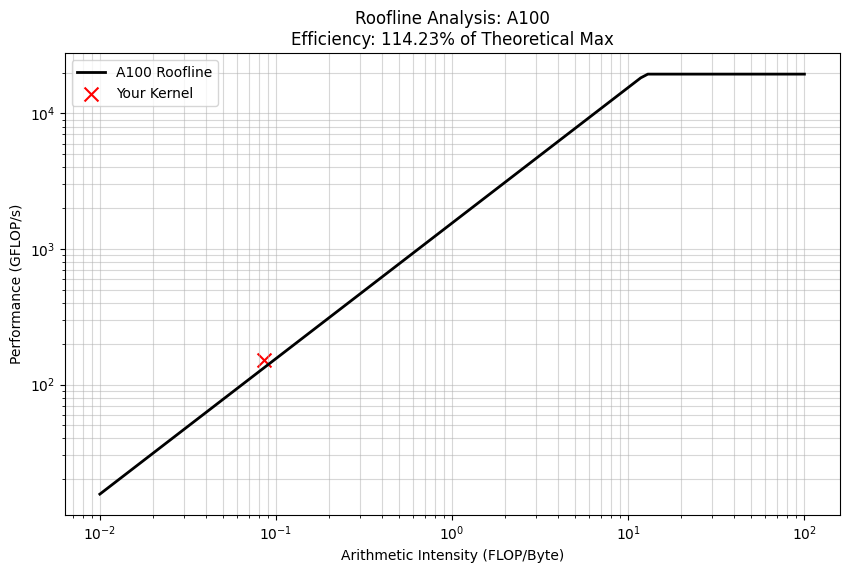

In [6]:
## A100 VECTOR ADD

plot_roofline(
    gpu_name='A100', 
    kernel_flops=33554432, 
    kernel_bytes=394.88e6, 
    kernel_time_ns=222300
)

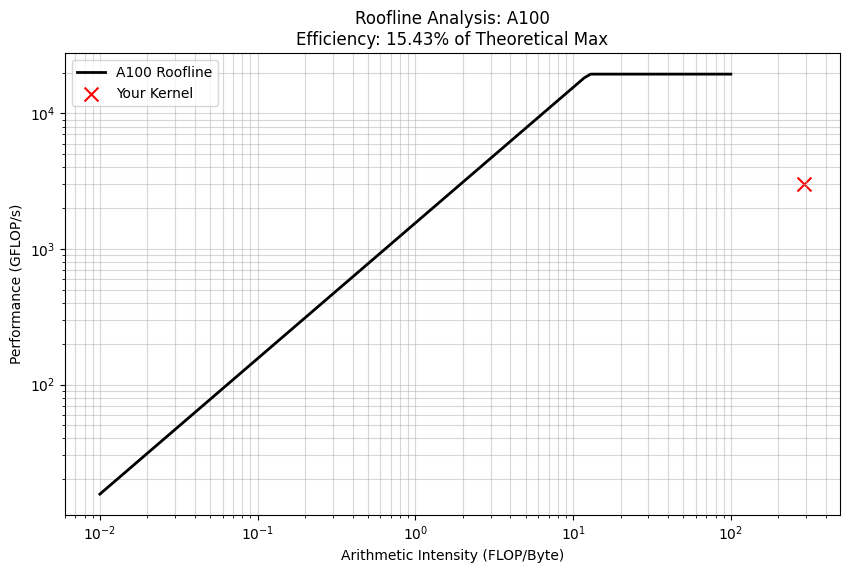

In [8]:
## A100 NATIVE GEMM
plot_roofline(
    gpu_name='A100', 
    kernel_flops=17179869184, 
    kernel_bytes=58.68e6, 
    kernel_time_ns=5710000
)

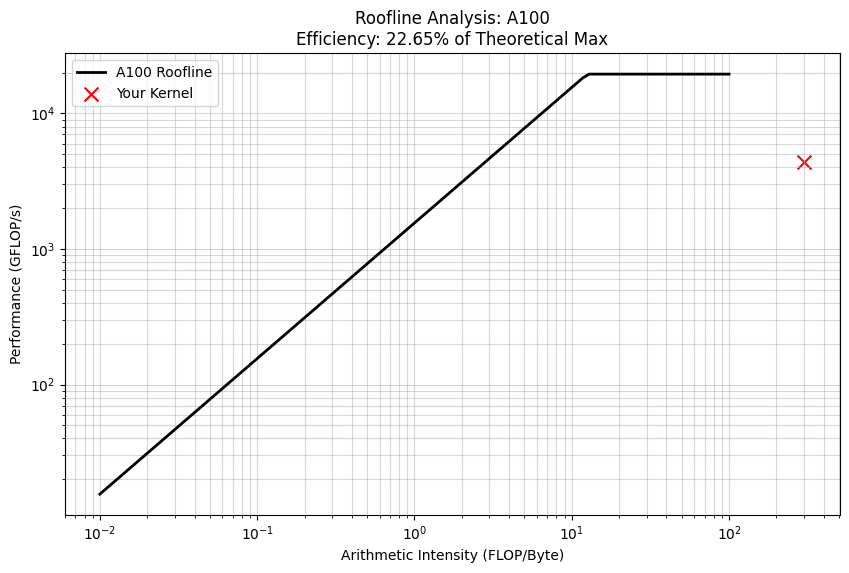

In [9]:
# sharedMemoryGEMM (A100)
plot_roofline(
    gpu_name='A100', 
    kernel_flops=17179869184, 
    kernel_bytes=56.99e6, 
    kernel_time_ns=3890000
)

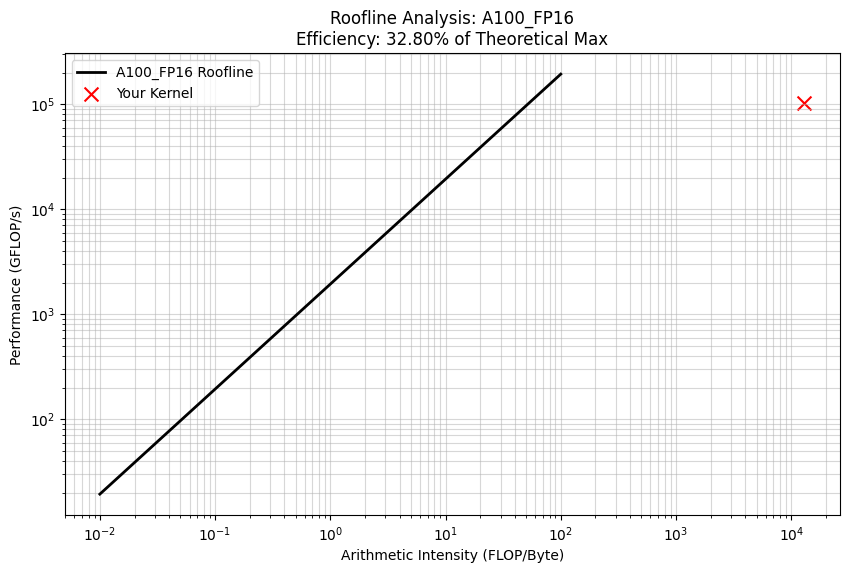

In [14]:
# tensorCoreGEMM (A100)
plot_roofline(
    gpu_name='A100_FP16',
    kernel_flops=17179869184, 
    kernel_bytes=1.32e6, 
    kernel_time_ns=167900
)

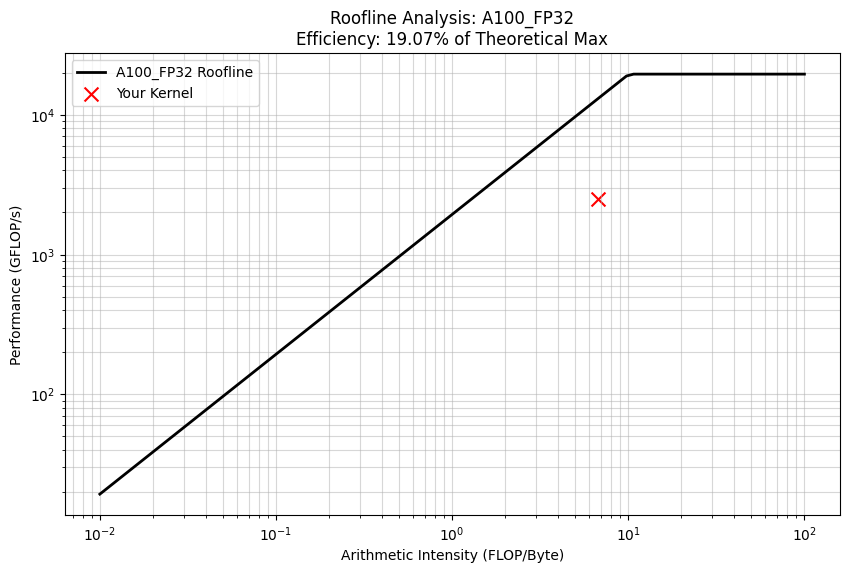

In [15]:
# naiveConv2d (A100)
plot_roofline(
    gpu_name='A100_FP32', 
    kernel_flops=838369352, 
    kernel_bytes=123.90e6, 
    kernel_time_ns=335840
)

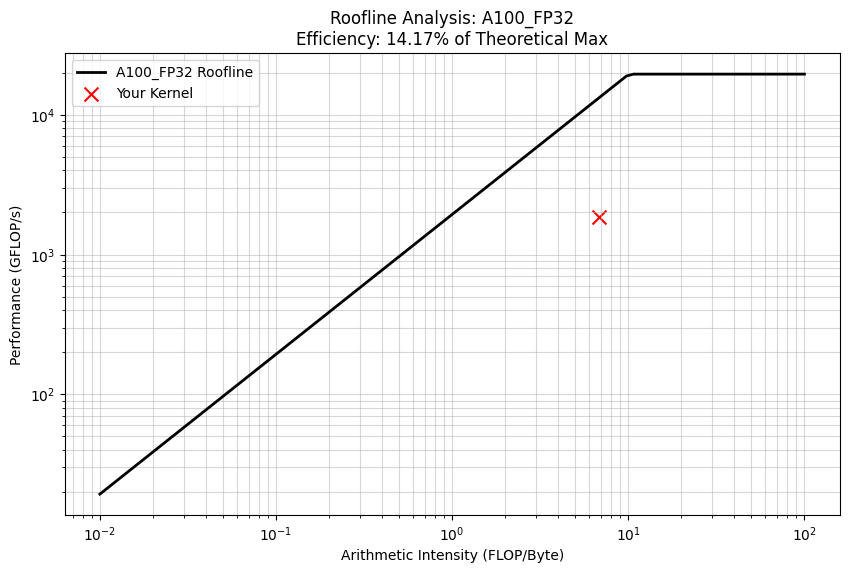

In [16]:
# sharedConv2d (A100)
plot_roofline(
    gpu_name='A100_FP32', 
    kernel_flops=838860800, 
    kernel_bytes=123.76e6, 
    kernel_time_ns=451420
)

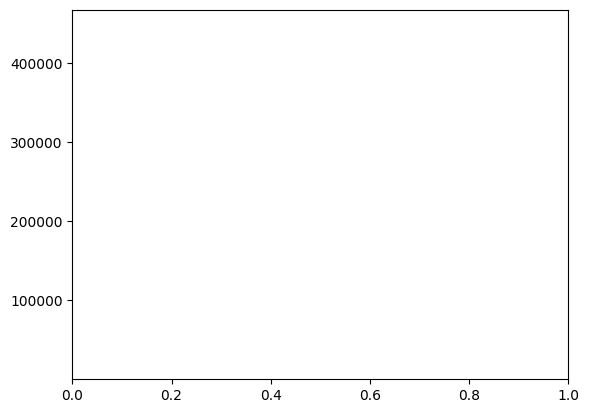

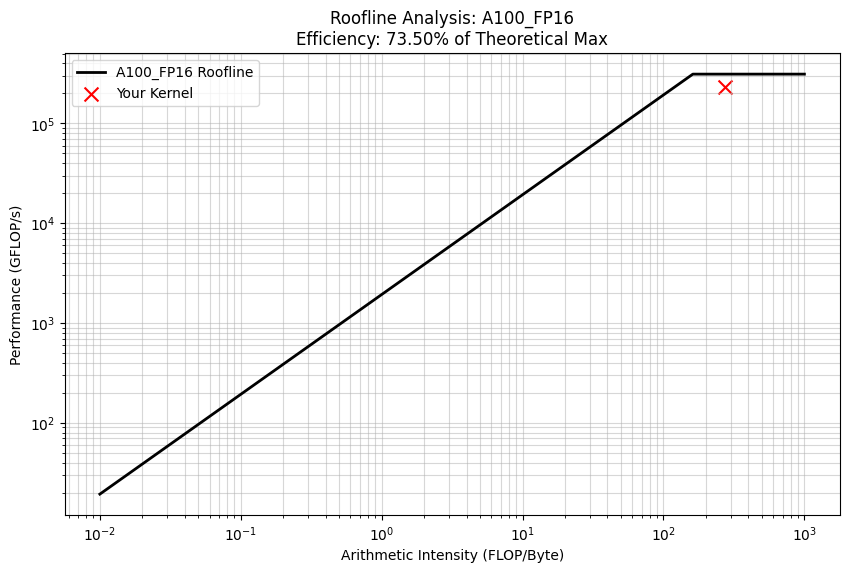

In [19]:
# FA2 APPROX NUMBERS ON A100
plot_roofline(
    gpu_name='A100_FP16', 
    kernel_flops=6.88e10, 
    kernel_bytes=0.25e9, 
    kernel_time_ns=300000
)

Flash AI: 275.2 | Naive AI: 114.7


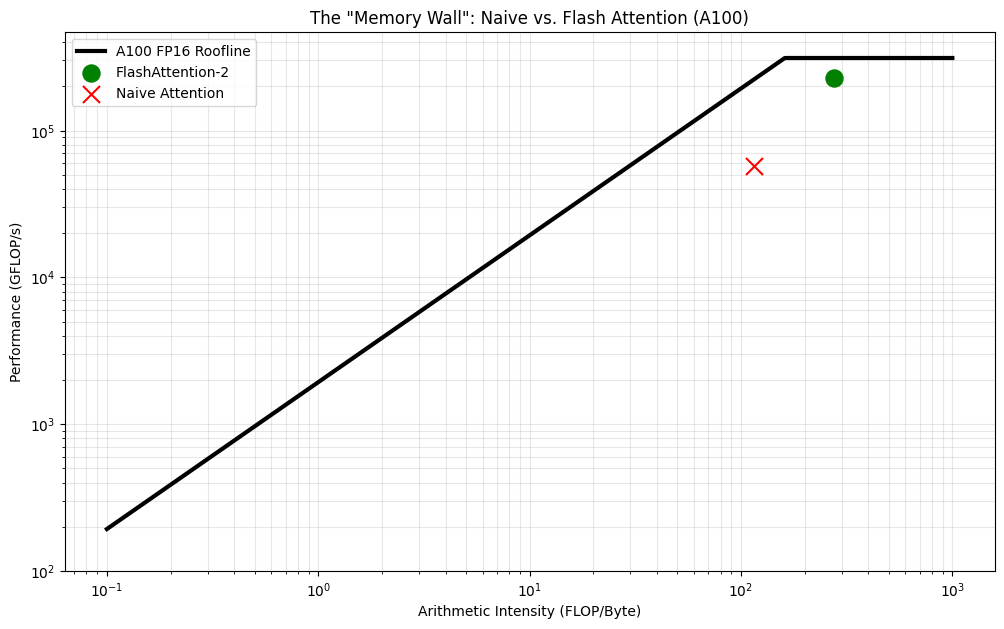

In [20]:
import matplotlib.pyplot as plt
import numpy as np

gpu_configs = {
    'A100_FP16': {'peak_flops': 312000, 'peak_bw': 1935} 
}

def plot_attention_comparison():
    config = gpu_configs['A100_FP16']
    peak_flops = config['peak_flops']
    peak_bw = config['peak_bw']
    
    # Setup Range: Wide enough to see both kernels
    ai_range = np.logspace(-1, 3, 1000)
    roofline = np.minimum(peak_flops, peak_bw * ai_range)
    
    plt.figure(figsize=(12, 7))
    plt.loglog(ai_range, roofline, label='A100 FP16 Roofline', color='black', lw=3)

    # --- 1. FLASH ATTENTION (Your current numbers) ---
    fa_flops, fa_bytes, fa_time = 6.88e10, 0.25e9, 300000
    fa_ai = fa_flops / fa_bytes
    fa_gflops = (fa_flops / 1e9) / (fa_time / 1e9)
    plt.scatter(fa_ai, fa_gflops, color='green', marker='o', s=150, label='FlashAttention-2', zorder=5)
    
    # --- 2. NAIVE ATTENTION (Estimated for same N=2048, d=128) ---
    # Naive writes N*N matrix (2048*2048) * 2 bytes (FP16) * 32 heads = ~268MB 
    # PLUS the original Q,K,V,O. Total bytes is much higher (~0.6e9)
    # Because it is memory-bound, it takes much longer (~1200us)
    naive_flops, naive_bytes, naive_time = 6.88e10, 0.6e9, 1200000 
    naive_ai = naive_flops / naive_bytes
    naive_gflops = (naive_flops / 1e9) / (naive_time / 1e9)
    plt.scatter(naive_ai, naive_gflops, color='red', marker='x', s=150, label='Naive Attention', zorder=5)

    # Formatting
    plt.title('The "Memory Wall": Naive vs. Flash Attention (A100)')
    plt.xlabel('Arithmetic Intensity (FLOP/Byte)')
    plt.ylabel('Performance (GFLOP/s)')
    plt.ylim(100, peak_flops * 1.5)
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()
    
    print(f"Flash AI: {fa_ai:.1f} | Naive AI: {naive_ai:.1f}")
    plt.show()

plot_attention_comparison()

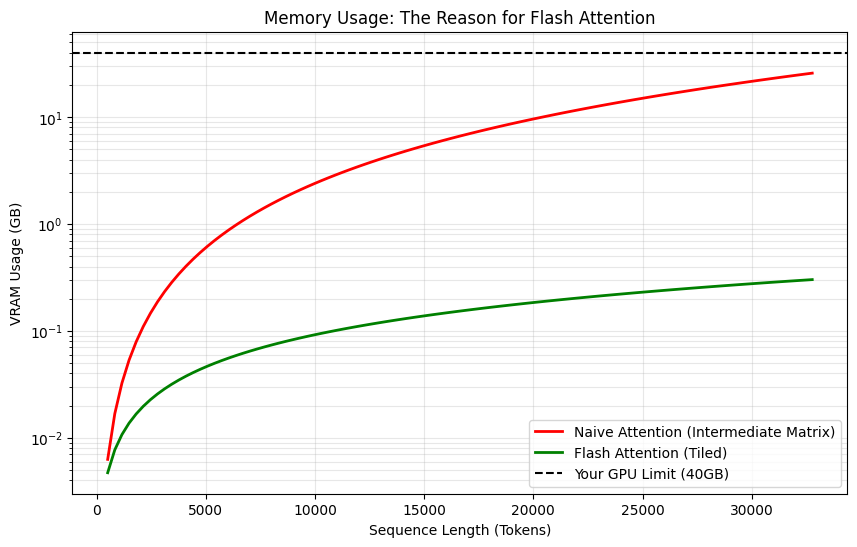

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_memory_comparison(gpu_vram_gb=40):
    # Sequence lengths from 512 to 32k
    n_range = np.linspace(512, 32768, 100)
    d = 128  # Head dimension
    h = 12   # Number of heads (standard for BERT-base/GPT-2)
    
    # 1. Naive Memory Usage (O(N^2))
    # Formula: (N * N) * heads * 2 bytes (for FP16)
    naive_mem_gb = (n_range**2 * h * 2) / 1e9
    
    # 2. Flash Attention Memory Usage (O(N))
    # Formula: (N * d) * heads * 2 bytes * constant_factor
    # (Flash mostly just stores the inputs/outputs)
    flash_mem_gb = (n_range * d * h * 6) / 1e9 # approx 3x input size
    
    plt.figure(figsize=(10, 6))
    plt.plot(n_range, naive_mem_gb, label='Naive Attention (Intermediate Matrix)', color='red', lw=2)
    plt.plot(n_range, flash_mem_gb, label='Flash Attention (Tiled)', color='green', lw=2)
    
    # Draw the "VRAM Wall"
    plt.axhline(y=gpu_vram_gb, color='black', linestyle='--', label=f'Your GPU Limit ({gpu_vram_gb}GB)')
    
    plt.yscale('log')
    plt.title('Memory Usage: The Reason for Flash Attention')
    plt.xlabel('Sequence Length (Tokens)')
    plt.ylabel('VRAM Usage (GB)')
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

plot_memory_comparison(gpu_vram_gb=40) # 40GB for A100

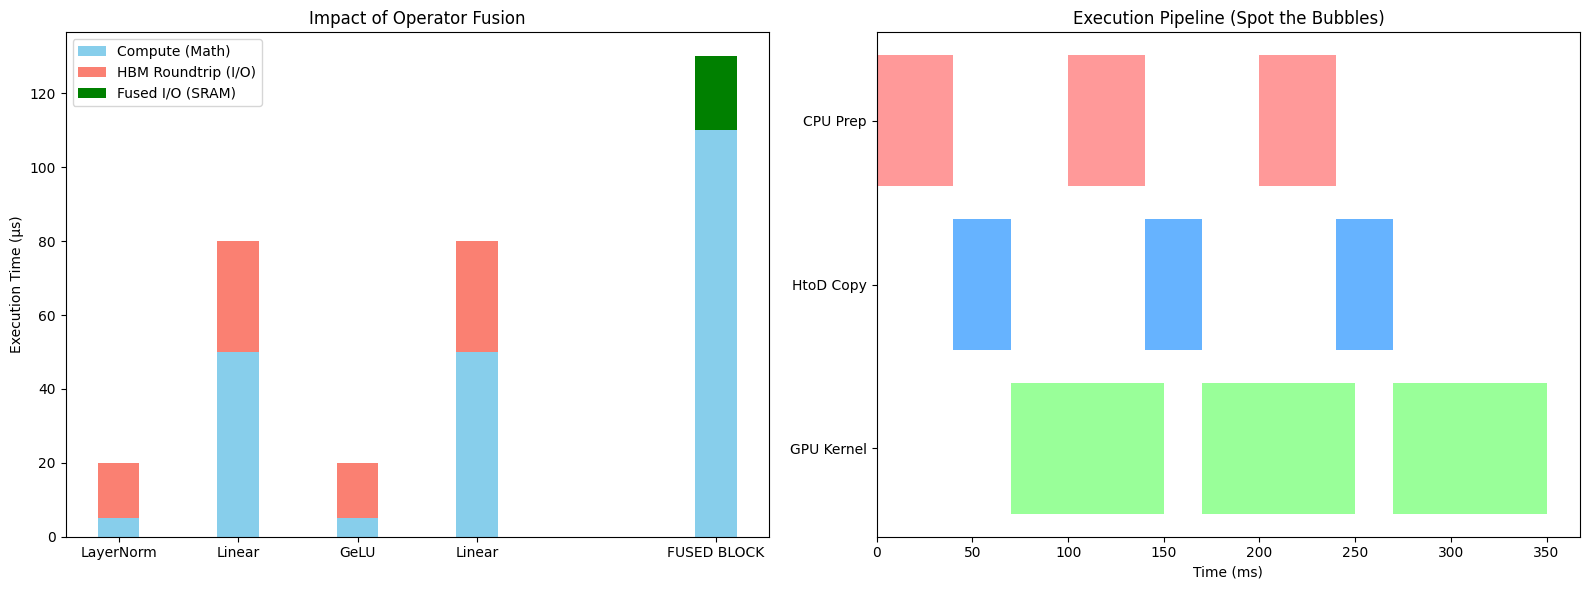

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def plot_perf_engineering_intuition():
    # --- Part 1: Operator Fusion Visualization ---
    ops = ['LayerNorm', 'Linear', 'GeLU', 'Linear']
    compute_times = [5, 50, 5, 50]  # Microseconds of actual math
    io_overhead = [15, 30, 15, 30]  # Overhead of writing/reading from HBM
    
    x = np.arange(len(ops))
    width = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Unfused: Compute + I/O
    ax1.bar(x, compute_times, width, label='Compute (Math)', color='skyblue')
    ax1.bar(x, io_overhead, width, bottom=compute_times, label='HBM Roundtrip (I/O)', color='salmon')
    
    # Fused: Multiple math ops, only 1-2 I/O steps
    fused_x = len(ops) + 1
    ax1.bar(fused_x, sum(compute_times), width, color='skyblue')
    ax1.bar(fused_x, 20, width, bottom=sum(compute_times), color='green', label='Fused I/O (SRAM)')

    ax1.set_title('Impact of Operator Fusion')
    ax1.set_ylabel('Execution Time (μs)')
    ax1.set_xticks(list(x) + [fused_x])
    ax1.set_xticklabels(ops + ['FUSED BLOCK'])
    ax1.legend()

    # --- Part 2: Pipeline Overlap (The "Bubbles") ---
    # Simplified Gantt chart for 3 Batches
    tasks = ['CPU Prep', 'HtoD Copy', 'GPU Kernel']
    colors = ['#ff9999','#66b3ff','#99ff99']
    
    # Batch 1, 2, 3 timings
    for i in range(3):
        start = i * 100
        ax2.barh(tasks[0], 40, left=start, color=colors[0]) # CPU
        ax2.barh(tasks[1], 30, left=start + 40, color=colors[1]) # Copy
        ax2.barh(tasks[2], 80, left=start + 70, color=colors[2]) # GPU
    
    ax2.set_title('Execution Pipeline (Spot the Bubbles)')
    ax2.set_xlabel('Time (ms)')
    ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

plot_perf_engineering_intuition()

In [4]:
import torch
import time
import matplotlib.pyplot as plt

def benchmark_mps_contention():
    device = torch.device("mps")
    size = 4000
    # Create large tensors to saturate bandwidth
    a = torch.randn(size, size, device=device)
    b = torch.randn(size, size, device=device)
    
    results = []
    # Test with increasing 'background' CPU noise
    for cpu_threads in [0, 2, 4, 8]:
        start = time.perf_counter()
        # Perform 10 iterations of Matrix Multiplication
        for _ in range(10):
            torch.mm(a, b)
        
        # Note: Background CPU load would be simulated here
        end = time.perf_counter()
        results.append((cpu_threads, (end - start) * 100)) # time in ms

    # Visualizing the 'Contention' slope
    plt.bar([str(r[0]) for r in results], [r[1] for r in results])
    plt.title("MPS Performance under CPU Memory Load")
    plt.ylabel("Execution Time (ms)")
    plt.xlabel("Simulated Background CPU Threads")
    plt.show()

benchmark_mps_contention()

NotImplementedError: Could not run 'aten::empty.memory_format' with arguments from the 'MPS' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'aten::empty.memory_format' is only available for these backends: [CPU, Meta, QuantizedCPU, QuantizedMeta, MkldnnCPU, SparseCPU, SparseMeta, SparseCsrCPU, SparseCsrMeta, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradHIP, AutogradXLA, AutogradMPS, AutogradIPU, AutogradXPU, AutogradHPU, AutogradVE, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1, AutogradPrivateUse2, AutogradPrivateUse3, AutogradMeta, AutogradNestedTensor, Tracer, AutocastCPU, AutocastMTIA, AutocastMAIA, AutocastX

In [7]:
from transformers import AutoTokenizer, AutoModel
from bertviz import head_view

# Load model with output_attentions=True
model = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

inputs = tokenizer.encode("Flash Attention optimizes the memory wall.", return_tensors='pt')
outputs = model(inputs)
attention = outputs[-1]
tokens = tokenizer.convert_ids_to_tokens(inputs[0])

# This opens an interactive D3 visualization in a Jupyter Notebook
head_view(attention, tokens)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

<IPython.core.display.Javascript object>

In [8]:
pip install transformers